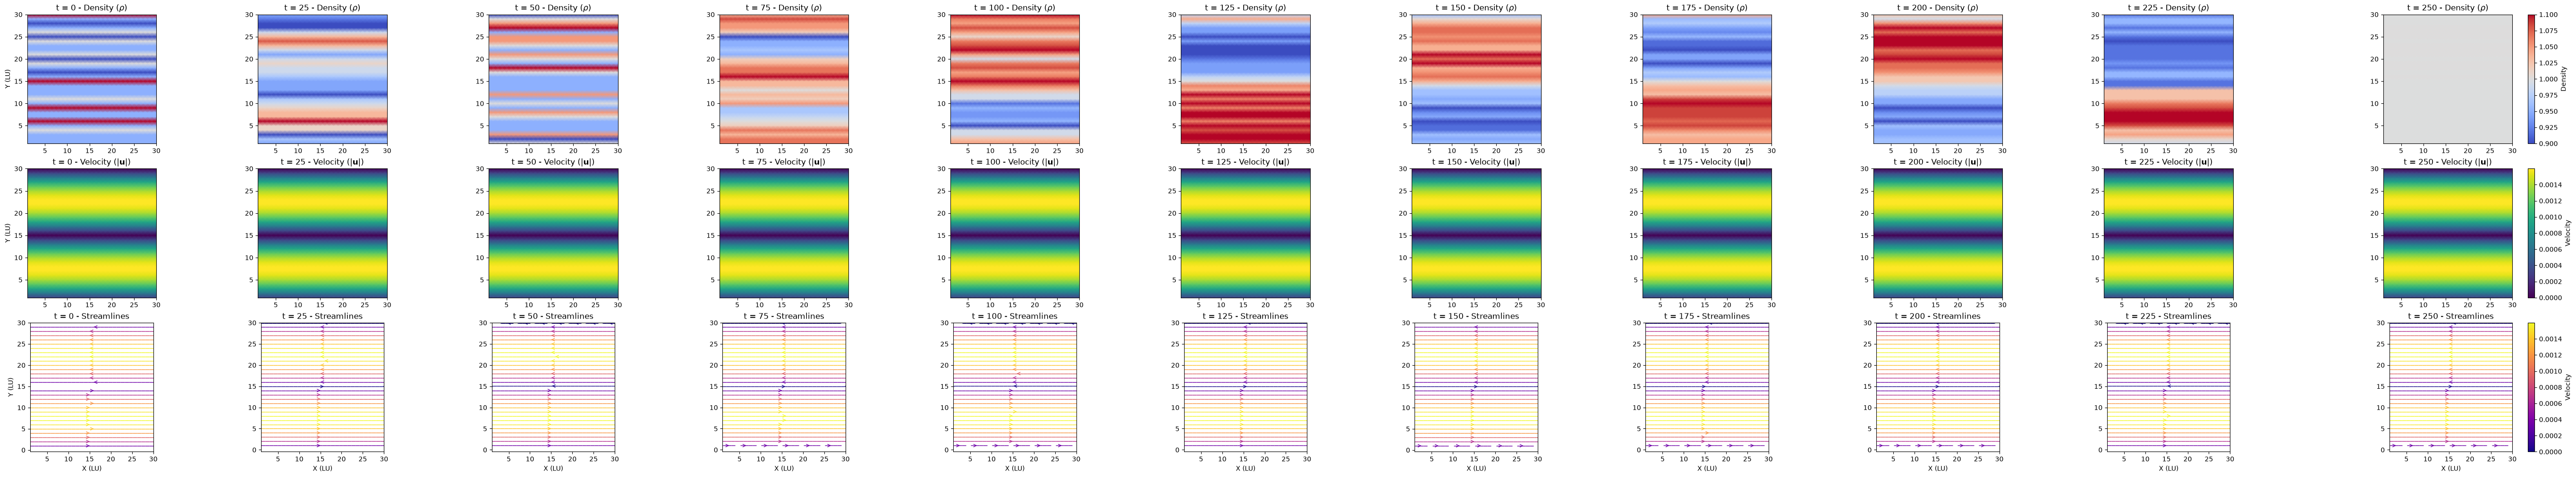

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def load_and_smooth_data(filename, sigma=1.0):
    """
    Loads data and applies Gaussian smoothing to suppress noise.
    """
    # ... (Keep your existing data loading logic here) ...
    # After defining Rho, U, V:
    
    # Apply Gaussian filter for macroscopic view
    # sigma controls the intensity of smoothing
    Rho = gaussian_filter(Rho, sigma=sigma)
    U = gaussian_filter(U, sigma=sigma)
    V = gaussian_filter(V, sigma=sigma)
    vel_mag = np.sqrt(U**2 + V**2)
    
    return X, Y, U, V, Rho, vel_mag

def get_robust_limits(data, percentile_clip=2):
    """Calculates limits excluding extreme outliers."""
    vmin = np.percentile(data, percentile_clip)
    vmax = np.percentile(data, 100 - percentile_clip)
    return vmin, vmax

def load_lbm_data_from_txt(filename):
    """
    Loads LBM data from a text file formatted as: x, y, rho, ux, uy
    """
    try:
        data = np.loadtxt(filename, delimiter=',')
    except Exception as e:
        print(f"Error reading {filename}. Details: {e}")
        return None

    x_1d, y_1d = data[:, 0], data[:, 1]
    rho_1d = data[:, 2]
    ux_1d, uy_1d = data[:, 3], data[:, 4]

    x_unique, y_unique = np.unique(x_1d), np.unique(y_1d)
    nx, ny = len(x_unique), len(y_unique)
    dx = x_unique[1] - x_unique[0] if nx > 1 else 1.0
    dy = y_unique[1] - y_unique[0] if ny > 1 else 1.0

    X, Y = np.meshgrid(x_unique, y_unique)
    U, V, Rho = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))

    col_indices = np.round((x_1d - x_unique[0]) / dx).astype(int)
    row_indices = np.round((y_1d - y_unique[0]) / dy).astype(int)

    U[row_indices, col_indices] = ux_1d
    V[row_indices, col_indices] = uy_1d
    Rho[row_indices, col_indices] = rho_1d

    vel_mag = np.sqrt(U**2 + V**2)

    return X, Y, U, V, Rho, vel_mag

def visualize_multiple_timesteps(filenames, step_labels=None):
    """
    Creates a side-by-side comparison grid for multiple LBM time steps.
    Rows: Density, Velocity Magnitude, Streamlines.
    Columns: Time steps.
    """
    num_steps = len(filenames)
    if num_steps == 0:
        print("No files provided.")
        return

    # If no labels are provided, just use "Step 1, Step 2, etc."
    if step_labels is None:
        step_labels = [f"Time Step {i+1}" for i in range(num_steps)]

    # Create a grid: 3 rows (variables), N columns (time steps)
    # Adjust the figsize dynamically based on how many files are loaded
    fig, axes = plt.subplots(3, num_steps, figsize=(5 * num_steps, 10), constrained_layout=True)
    
    # If there is only one file, axes is 1D. Let's make it 2D for consistent indexing
    if num_steps == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for col, (filename, label) in enumerate(zip(filenames, step_labels)):
        result = load_lbm_data_from_txt(filename)
        if result is None:
            continue
        
        X, Y, u, v, Rho, vel_mag = result
        x_1d, y_1d = X[0, :], Y[:, 0]

        # Row 0: Density
        ax_rho = axes[0, col]
        vmin_rho, vmax_rho = get_robust_limits(Rho)
        mesh_rho = ax_rho.pcolormesh(X, Y, Rho, vmin=vmin_rho, vmax=vmax_rho, shading='gouraud', cmap='coolwarm')
        ax_rho.set_title(rf"{label} - Density ($\rho$)", fontsize=12)
        ax_rho.set_aspect('equal')
        # Only add Y-label on the far left column to keep the grid clean
        if col == 0: ax_rho.set_ylabel("Y (LU)")
        # Put the colorbar only on the far right column
        if col == num_steps - 1: fig.colorbar(mesh_rho, ax=ax_rho, label="Density")

        # Row 1: Velocity Magnitude
        ax_vel = axes[1, col]
        vmin_vel, vmax_vel = get_robust_limits(vel_mag)
        mesh_vel = ax_vel.pcolormesh(X, Y, vel_mag, vmin=vmin_vel, vmax=vmax_vel, shading='gouraud', cmap='viridis')
        ax_vel.set_title(rf"{label} - Velocity ($|\mathbf{{u}}|$)", fontsize=12)
        ax_vel.set_aspect('equal')
        if col == 0: ax_vel.set_ylabel("Y (LU)")
        if col == num_steps - 1: fig.colorbar(mesh_vel, ax=ax_vel, label="Velocity")

        # Row 2: Streamlines
        ax_strm = axes[2, col]
        strm = ax_strm.streamplot(x_1d, y_1d, u, v, color=vel_mag, cmap='plasma', 
                                  linewidth=1, density=1.0, arrowstyle='->', arrowsize=1)
        ax_strm.set_title(f"{label} - Streamlines", fontsize=12)
        ax_strm.set_xlabel("X (LU)")
        ax_strm.set_aspect('equal')
        if col == 0: ax_strm.set_ylabel("Y (LU)")
        if col == num_steps - 1: fig.colorbar(strm.lines, ax=ax_strm, label="Velocity")
        
    plt.show()

if __name__ == "__main__":
    interval = 10
    interval_length = 25
    data_files = ["output-0.txt"]
    labels = ["t = 0"]
    for i in range (1, interval+1):
        data_files.append("output-" + str(i * interval_length) + ".txt")
        labels.append("t = " + str(i * interval_length))
    
    visualize_multiple_timesteps(data_files, step_labels=labels)

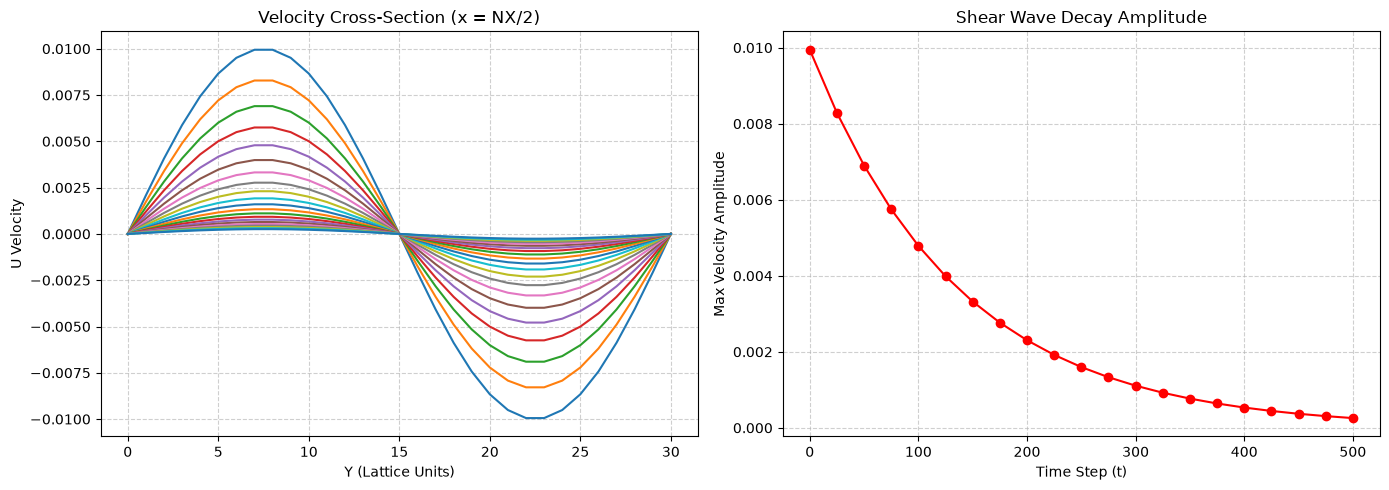

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def generate_lbd2q9_graphs_from_files(data_files, timesteps):
    T = []
    amp = []
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for file, t in zip(data_files, timesteps):
        try:
            # Read the data: x, y, rho, ux, uy
            data = np.loadtxt(file, delimiter=',')
            
            # Sort data by y then x to ensure consistent reshaping
            # Lexicographical sort: column 1 (y), then column 0 (x)
            data = data[np.lexsort((data[:, 0], data[:, 1]))]
            
            # Determine grid dimensions
            NX = len(np.unique(data[:, 0]))
            NY = len(np.unique(data[:, 1]))
            
            # Extract U-velocity (index 3) and reshape to (NY, NX)
            if data.shape[1] >= 4:
                U = data[:, 3].reshape((NY, NX))
            else:
                raise ValueError(f"File {file} does not have enough columns (expected 5, found {data.shape[1]})")
                
            # Extract velocity cross-section at middle of X
            u_slice = U[:, NX//2]
            u_slice = np.append(u_slice, u_slice[0])
            ax1.plot(u_slice, label=f't = {t}')
            
            # Extract maximum amplitude
            max_amp = np.max(np.abs(u_slice))
            T.append(t)
            amp.append(max_amp)
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
            
    # Plot formatting
    ax1.set_title("Velocity Cross-Section (x = NX/2)")
    ax1.set_xlabel("Y (Lattice Units)")
    ax1.set_ylabel("U Velocity")
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.plot(T, amp, marker='o', linestyle='-', color='red')
    ax2.set_title("Shear Wave Decay Amplitude")
    ax2.set_xlabel("Time Step (t)")
    ax2.set_ylabel("Max Velocity Amplitude")
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    interval = 20
    interval_length = 25
    data_files = ["output-0-k.txt"]
    timesteps = [0]
    for i in range (1, interval+1):
        data_files.append("output-" + str(i * interval_length) + "-k.txt")
        timesteps.append(i * interval_length)
    generate_lbd2q9_graphs_from_files(data_files, timesteps)

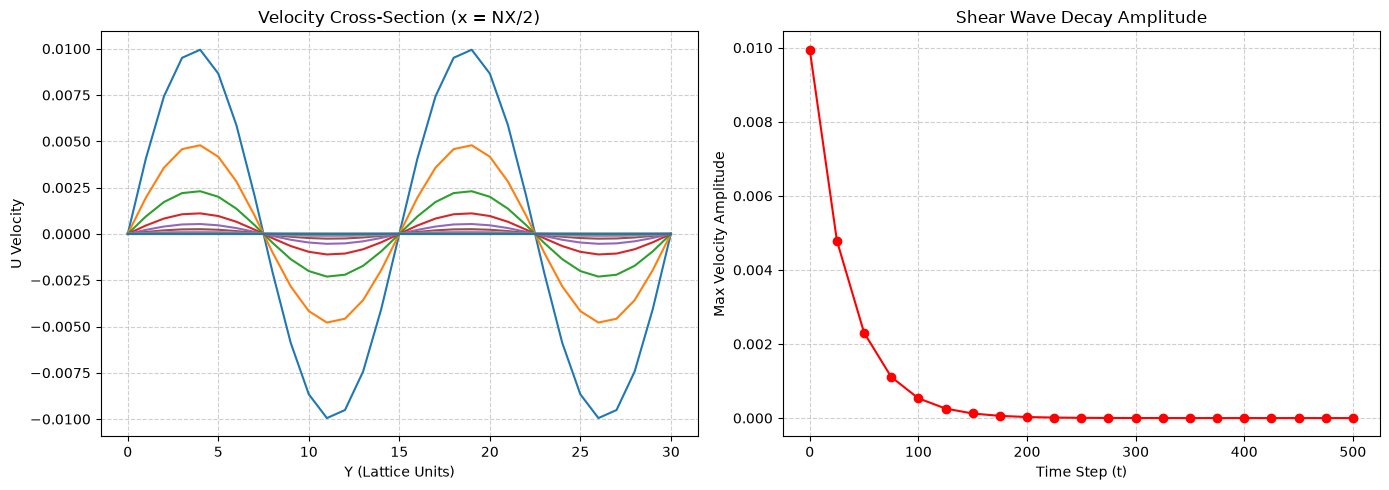

In [9]:
if __name__ == "__main__":
    interval = 20
    interval_length = 25
    data_files = ["output-0-2k.txt"]
    timesteps = [0]
    for i in range (1, interval+1):
        data_files.append("output-" + str(i * interval_length) + "-2k.txt")
        timesteps.append(i * interval_length)
    generate_lbd2q9_graphs_from_files(data_files, timesteps)